In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.inspection import PartialDependenceDisplay

In [ ]:
#Load the Dataset
data = fetch_california_housing()
x = data.data
y = data.target

#Splitting the dataset for training and testing
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test,rf_pred)
rf_r2 = r2_score(y_test,rf_pred)

In [ ]:
#model Result
print("Random Forest Regressor")
print("Mean Squared Error: ",rf_mse)
print("R2 Score: ",rf_r2)

Random Forest Regressor
Mean Squared Error:  0.2553684927247781
R2 Score:  0.8051230593157366


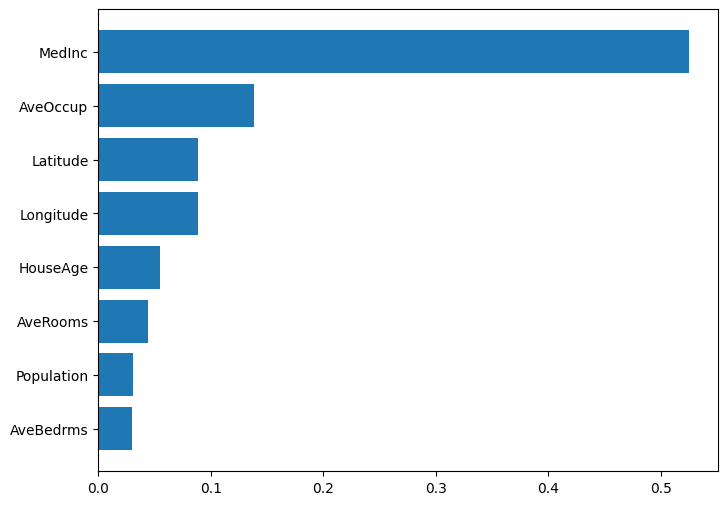

In [ ]:
# Feature Importance Visualization

importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize = (8,6))
plt.barh(range(len(indices)),importances[indices])
plt.yticks(range(len(indices)),[data.feature_names[i] for i in indices])
plt.show()

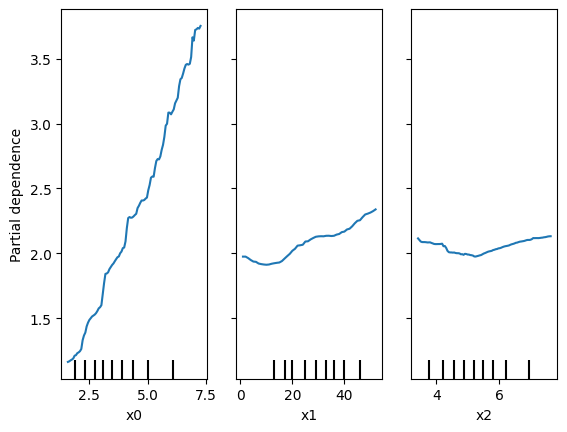

In [ ]:
# Partial Dependence plots
features_to_plot = [0,1,2]
PartialDependenceDisplay.from_estimator(rf_model,X_test,features=features_to_plot)
plt.show()